In [4]:
import pandas as pd

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

# Combine
df_all = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria])

print(df_all.columns)

# Check
df_all["Country"].value_counts()

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Date', 'Month'],
      dtype='object')


Country
Ethiopia    4108
Kenya       4108
Sudan       4108
Tanzania    4108
Nigeria     4108
Name: count, dtype: int64

Temperature Trend Comparison

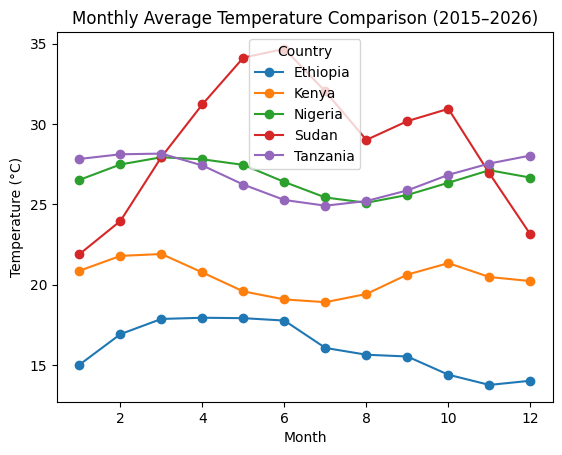

In [5]:
import matplotlib.pyplot as plt

monthly_temp = df_all.groupby(["Country", "Month"])["T2M"].mean().unstack(0)

monthly_temp.plot(marker="o")
plt.title("Monthly Average Temperature Comparison (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.legend(title="Country")
plt.show()

Summary Table (Temperature)

In [6]:
temp_summary = df_all.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


Precipitation Variability

Boxplot

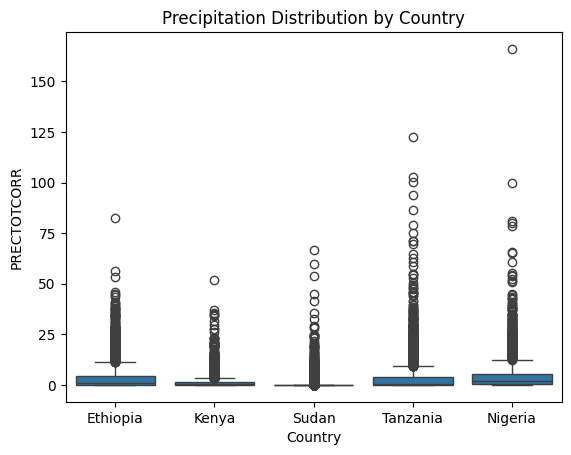

In [7]:
import seaborn as sns

sns.boxplot(x="Country", y="PRECTOTCORR", data=df_all)
plt.title("Precipitation Distribution by Country")
plt.show()

Summary Table

In [8]:
rain_summary = df_all.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
rain_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


Extreme Events

Extreme Heat (>35°C)

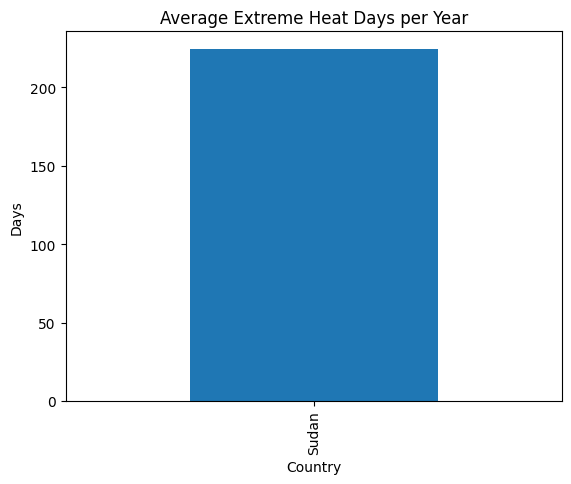

In [9]:
extreme_heat = df_all[df_all["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby(["Country", "YEAR"]).size().groupby("Country").mean()

heat_counts.plot(kind="bar")
plt.title("Average Extreme Heat Days per Year")
plt.ylabel("Days")
plt.show()

Consecutive Dry Days

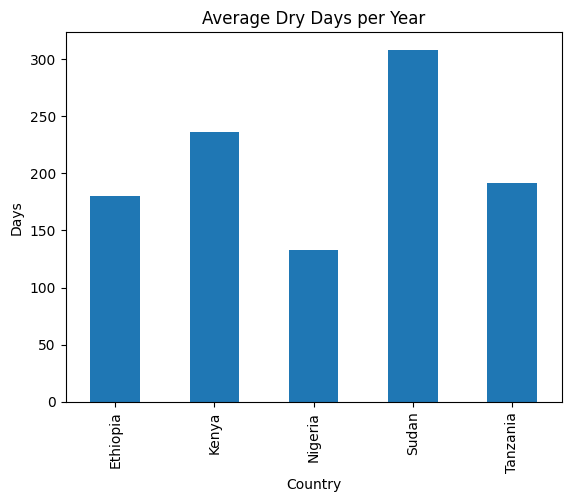

In [10]:
df_all["Dry"] = df_all["PRECTOTCORR"] < 1

dry_counts = df_all.groupby("Country")["Dry"].sum() / df_all["YEAR"].nunique()

dry_counts.plot(kind="bar")
plt.title("Average Dry Days per Year")
plt.ylabel("Days")
plt.show()

# Sudan experiences the highest frequency of extreme heat and prolonged dry conditions, indicating significant climate stress.

Statistical Testing (IMPORTANT FOR MARKS)

ANOVA Test

In [11]:
from scipy.stats import f_oneway

groups = [group["T2M"].dropna() for name, group in df_all.groupby("Country")]

f_stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

P-value: 0.0


Interpretation
since p < 0.05:

# There is a statistically significant difference in temperature across countries.

Vulnerability Ranking Table

In [12]:
ranking = pd.DataFrame({
    "Country": temp_summary.index,
    "Avg Temp": temp_summary["mean"],
    "Rain Variability": rain_summary["std"],
    "Extreme Heat Days": heat_counts,
    "Dry Days": dry_counts
})

ranking = ranking.sort_values(by=["Extreme Heat Days", "Dry Days"], ascending=False)

ranking

,Country,Avg Temp,Rain Variability,Extreme Heat Days,Dry Days
Country,,,,,
Sudan,Sudan,28.759007,3.057672,224.5,308.000000
Kenya,Kenya,20.427600,3.180228,NaN,235.916667
Tanzania,Tanzania,26.802422,8.003947,NaN,191.916667
Ethiopia,Ethiopia,16.068500,6.289061,NaN,180.083333
Nigeria,Nigeria,26.656928,7.266742,NaN,132.916667


## Climate Vulnerability Insights for COP32
* Warming Trends:
Sudan records the highest average temperature among the five countries, with a mean temperature of approximately 28.8°C. The country also exhibits the highest frequency of extreme heat days, where maximum temperatures exceed 35°C. This trend suggests increasing exposure to prolonged heat stress, which may negatively affect agriculture, water availability, and public health.
* Precipitation Instability:
Tanzania and Nigeria demonstrate the highest precipitation variability, with standard deviations of 8.00 mm and 7.27 mm respectively. High rainfall variability indicates irregular precipitation patterns, increasing the likelihood of both flooding and seasonal unpredictability. Such instability poses risks to food security, infrastructure, and water resource management.
* Extreme Heat and Drought Exposure:
Sudan experiences the greatest number of dry days per year, averaging approximately 308 dry days annually, alongside the highest occurrence of extreme heat events. These findings indicate severe climate stress and heightened vulnerability to drought conditions, desertification, and reduced agricultural productivity.
* Ethiopia’s Climate Profile:
Ethiopia records the lowest average temperature among the countries analyzed, with relatively moderate levels of dry-day frequency compared to Sudan and Kenya. However, the country shows considerable rainfall variability (standard deviation ≈ 6.29 mm), suggesting vulnerability to irregular seasonal rainfall patterns that may contribute to both drought and localized flooding risks.
* Implications for Climate Finance and COP32 Priorities:
Based on the combined evidence from temperature trends, precipitation variability, and extreme event frequency, Sudan emerges as the most climate-vulnerable country in this analysis. The data strongly supports prioritizing Sudan for climate adaptation financing and resilience-building initiatives at COP32, particularly in areas related to drought mitigation, heat adaptation, and sustainable water management.